Null Hypothesis: There is no linear relationship between a video game's rating and its global sales.

Alternative Hypothesis: There is a positive linear relationship between a video game's rating and its global sales.

--- HYPOTHESIS TEST RESULTS ---
Correlation Coefficient (r): 0.0733
P-value: 5.9292e-03

--- ANALYSIS ---
The result is Statistically Significant (p < 0.05).
However, the correlation is WEAK (r = 0.07).
This confirms the 'Quality-Popularity Gap': Ratings are not a strong predictor of Sales.


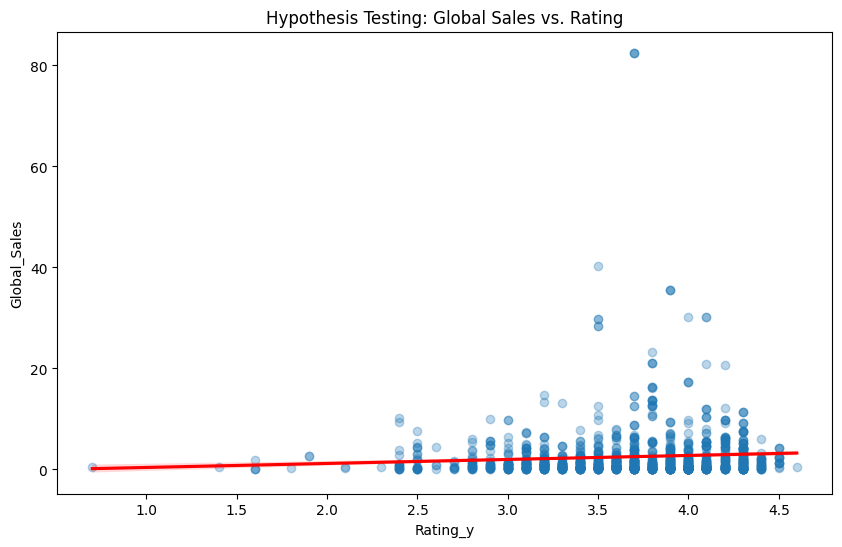

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df_sales = pd.read_csv('vgsales.csv.zip')
df_popular = pd.read_csv('games.csv.zip')

df_sales['Name_Clean'] = df_sales['Name'].astype(str).str.lower().str.strip()
df_popular['Title_Clean'] = df_popular['Title'].astype(str).str.lower().str.strip()
df_merged = pd.merge(df_sales, df_popular, left_on='Name_Clean', right_on='Title_Clean', how='inner')
target_col = None
for col in ['Rating', 'Rating_y', 'Rating_x']:
    if col in df_merged.columns:
        target_col = col
        break

if target_col:
    df_merged[target_col] = pd.to_numeric(df_merged[target_col], errors='coerce')
    df_merged['Global_Sales'] = pd.to_numeric(df_merged['Global_Sales'], errors='coerce')
    df_merged = df_merged.dropna(subset=['Global_Sales', target_col])
    r_coeff, p_value = pearsonr(df_merged[target_col], df_merged['Global_Sales'])
    print("--- HYPOTHESIS TEST RESULTS ---")
    print(f"Correlation Coefficient (r): {r_coeff:.4f}")
    print(f"P-value: {p_value:.4e}")
    print("\n--- ANALYSIS ---")
    if p_value < 0.05:
        print(f"The result is Statistically Significant (p < 0.05).")
        if r_coeff < 0.3:
            print(f"However, the correlation is WEAK (r = {r_coeff:.2f}).")
            print("This confirms the 'Quality-Popularity Gap': Ratings are not a strong predictor of Sales.")

        else:
            print("There is a notable positive correlation between quality and popularity.")
    else:
        print("The result is NOT statistically significant. No clear relationship was found.")

    plt.figure(figsize=(10, 6))
    sns.regplot(data=df_merged, x=target_col, y='Global_Sales',
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title('Hypothesis Testing: Global Sales vs. Rating')
    plt.show()

else:
    print("Error: Could not find a Rating column to test.")

--- ANALYSIS ---
The result is Statistically Significant (p < 0.05).
However, the correlation is WEAK (r = 0.07).
This confirms the 'Quality-Popularity Gap': Ratings are not a strong predictor of Sales.